In [34]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('credit_risk_dataset.csv')
conn = sqlite3.connect('Credit_Risk.db')

In [4]:
df.to_sql('credit_risk', conn, if_exists='replace', index=False)

32581

In [5]:
query = "select count(*) from credit_risk"
result = pd.read_sql(query,conn)
print(result)

   count(*)
0     32581


In [6]:
df.head(5)
df.shape
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  str    
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  str    
 5   loan_grade                  32581 non-null  str    
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  str    
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), str(4)
memory usage: 3.0 MB


In [7]:
query = """
SELECT count(loan_status)
FROM credit_risk
group by loan_status
"""
result = pd.read_sql(query, conn)
result

,count(loan_status)
0,25473
1,7108


In [8]:
query = """
SELECT DISTINCT loan_status
FROM credit_risk
"""
result = pd.read_sql(query, conn)
result

,loan_status
0,1
1,0


In [9]:
query = """
SELECT 
    COUNT(*) as total,
    SUM(loan_status) as total_default,
    ROUND(SUM(loan_status) * 100.0 / COUNT(*), 2) as default_rate
FROM credit_risk
"""
result = pd.read_sql(query, conn)
result

,total,total_default,default_rate
0,32581,7108,21.82


In [10]:
query = """
SELECT 
    loan_intent,
    COUNT(*) as total,
    SUM(loan_status) as total_default,
    ROUND(SUM(loan_status) * 100.0 / COUNT(*), 2) as default_rate
FROM credit_risk
group by loan_intent
order by default_rate desc
"""
result = pd.read_sql(query, conn)
result

,loan_intent,total,total_default,default_rate
0,DEBTCONSOLIDATION,5212,1490,28.59
1,MEDICAL,6071,1621,26.70
2,HOMEIMPROVEMENT,3605,941,26.10
3,PERSONAL,5521,1098,19.89
4,EDUCATION,6453,1111,17.22
5,VENTURE,5719,847,14.81


In [11]:
query = """
SELECT 
    loan_grade,
    COUNT(*) as total,
    SUM(loan_status) as total_default,
    ROUND(SUM(loan_status) * 100.0 / COUNT(*), 2) as default_rate
FROM credit_risk
group by loan_grade
order by default_rate desc
"""
result = pd.read_sql(query, conn)
result

,loan_grade,total,total_default,default_rate
0,G,64,63,98.44
1,F,241,170,70.54
2,E,964,621,64.42
3,D,3626,2141,59.05
4,C,6458,1339,20.73
5,B,10451,1701,16.28
6,A,10777,1073,9.96


In [14]:
query ="""
SELECT 
    cb_person_default_on_file,
    COUNT(*) as total,
    SUM(loan_status) as total_default,
    ROUND(SUM(loan_status) * 100.0 / COUNT(*), 2) as default_rate
FROM credit_risk
group by cb_person_default_on_file
order by default_rate desc
"""
result = pd.read_sql(query, conn)
result

,cb_person_default_on_file,total,total_default,default_rate
0,Y,5745,2172,37.81
1,N,26836,4936,18.39


In [28]:
query = """
SELECT 
    case
        when person_income <= 30000 then 'low_Income'
        when person_income > 30000 AND person_income <=80000 then 'Middle_income'
        else 'High_income'
        end As Income_category,
    count(*) as total,
    sum (loan_status) as total_default,
    round(sum(loan_status) * 100.0/count(*),2) as default_rate
    from credit_risk
    group by Income_category
    order by default_rate
    """
    
result = pd.read_sql(query, conn)
result

,Income_category,total,total_default,default_rate
0,High_income,7650,719,9.40
1,Middle_income,20415,4333,21.22
2,low_Income,4516,2056,45.53


In [30]:
query ="""
SELECT 
    loan_grade,
    COUNT(*) as total,
    SUM(loan_status) as total_default,
    avg(loan_int_rate) as avg_int_rate,
    ROUND(SUM(loan_status) * 100.0 / COUNT(*), 2) as default_rate
FROM credit_risk
group by loan_grade
order by default_rate desc
"""
result = pd.read_sql(query, conn)
result

,loan_grade,total,total_default,avg_int_rate,default_rate
0,G,64,63,20.251525,98.44
1,F,241,170,18.609159,70.54
2,E,964,621,17.009455,64.42
3,D,3626,2141,15.361448,59.05
4,C,6458,1339,13.463542,20.73
5,B,10451,1701,10.995555,16.28
6,A,10777,1073,7.327651,9.96


In [ ]:
query = """
SELECT 
    case
        when cb_person_cred_hist_length <= 5 then 'short'
        when cb_person_cred_hist_length >= 5 AND cb_person_cred_hist_length <=15 then 'Medium'
        else 'Long'
        end As History_Length,
    count(*) as total,
    sum (loan_status) as total_default,
    round(sum(loan_status) * 100.0/count(*),2) as default_rate
    from credit_risk
    group by History_length
    order by default_rate
    """
    
result = pd.read_sql(query, conn)
result

,History_Length,total,total_default,default_rate
0,Medium,11725,2420,20.64
1,Long,1142,248,21.72
2,short,19714,4440,22.52


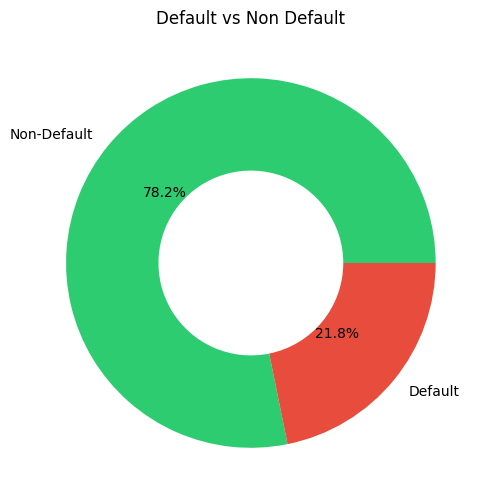

In [55]:
fig, ax =plt.subplots(figsize=(6,6))
labels = ['Non-Default','Default']
values = [25473,7109]
ax.pie(values,labels=labels,wedgeprops={'width':0.5},autopct='%1.1f%%',colors = ['#2ecc71', '#e74c3c'])
plt.title('Default vs Non Default')
plt.savefig('NDef vs Def.png', dpi=300, bbox_inches='tight')
plt.show()


In [43]:
query = """
SELECT 
    loan_grade,
    ROUND(SUM(loan_status) * 100.0 / COUNT(*), 2) as default_rate
FROM credit_risk
GROUP BY loan_grade
ORDER BY loan_grade desc
"""
df_grade = pd.read_sql(query, conn)
df_grade

,loan_grade,default_rate
0,G,98.44
1,F,70.54
2,E,64.42
3,D,59.05
4,C,20.73
5,B,16.28
6,A,9.96


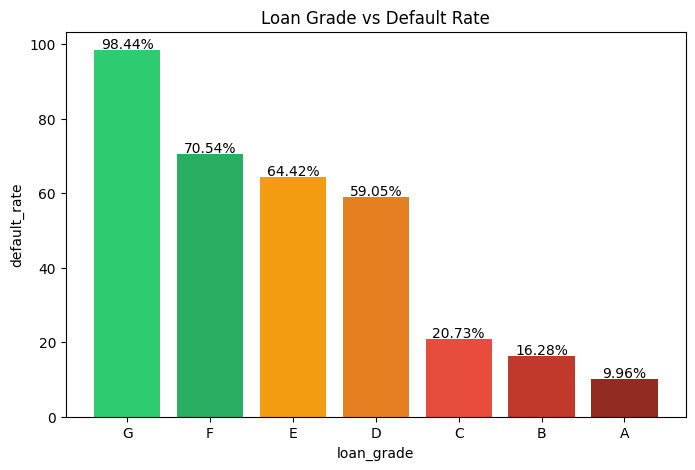

In [56]:
fig, ax = plt.subplots(figsize=(8,5))
ax.bar(df_grade['loan_grade'],df_grade['default_rate'], color = ['#2ecc71','#27ae60','#f39c12','#e67e22','#e74c3c','#c0392b','#922b21'])
plt.title('Loan Grade vs Default Rate')
plt.xlabel('loan_grade')
plt.ylabel('default_rate')
for i, v in enumerate(df_grade['default_rate']):
    ax.text(i, v + 0.5, f'{v}%', ha='center')
plt.savefig('LG vs DR.png', dpi=300, bbox_inches='tight')
plt.show()

In [48]:
query ="""
SELECT 
    cb_person_default_on_file,
    ROUND(SUM(loan_status) * 100.0 / COUNT(*), 2) as default_rate
FROM credit_risk
group by cb_person_default_on_file
order by default_rate desc
"""
df_person_default = pd.read_sql(query, conn)
df_person_default

,cb_person_default_on_file,default_rate
0,Y,37.81
1,N,18.39


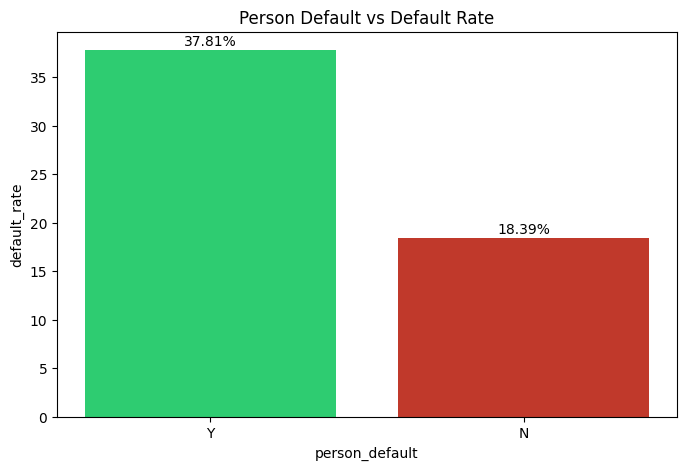

In [57]:
fig, ax = plt.subplots(figsize=(8,5))
ax.bar(df_person_default['cb_person_default_on_file'],df_person_default['default_rate'], color = ['#2ecc71','#c0392b'])
plt.title('Person Default vs Default Rate')
plt.xlabel('person_default')
plt.ylabel('default_rate')
for i, v in enumerate(df_person_default['default_rate']):
    ax.text(i, v + 0.5, f'{v}%', ha='center')
plt.savefig('PD vs DR.png', dpi=300, bbox_inches='tight')
plt.show()

In [53]:
query = """
SELECT 
    loan_grade,
    ROUND(AVG(loan_int_rate), 2) as avg_int_rate,
    ROUND(SUM(loan_status) * 100.0 / COUNT(*), 2) as default_rate
FROM credit_risk
GROUP BY loan_grade
ORDER BY loan_grade
"""
df_pricing = pd.read_sql(query, conn)
df_pricing

,loan_grade,avg_int_rate,default_rate
0,A,7.33,9.96
1,B,11.00,16.28
2,C,13.46,20.73
3,D,15.36,59.05
4,E,17.01,64.42
5,F,18.61,70.54
6,G,20.25,98.44


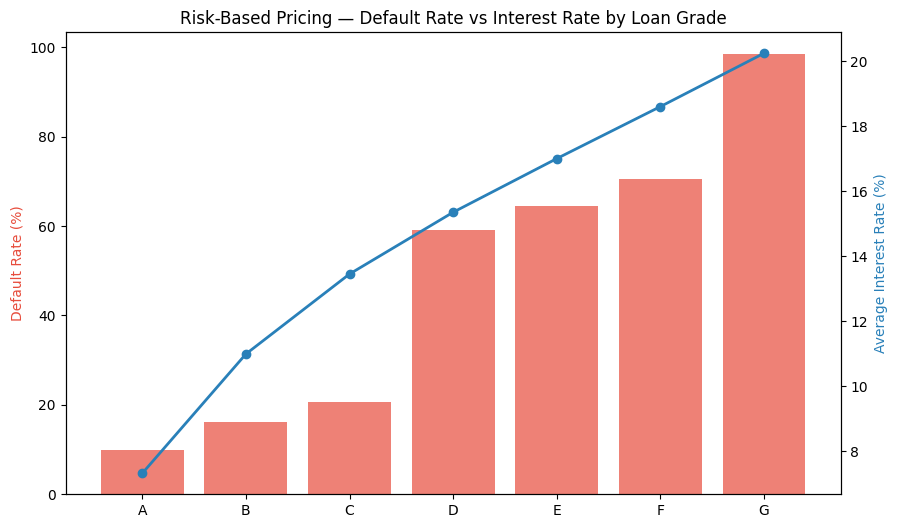

In [58]:
fig, ax1 = plt.subplots(figsize=(10, 6))

# Bar chart di axis kiri (ax1)
ax1.bar(df_pricing['loan_grade'], df_pricing['default_rate'], color='#e74c3c', alpha=0.7, label='Default Rate')
ax1.set_ylabel('Default Rate (%)', color='#e74c3c')

# Buat axis kanan (ax2)
ax2 = ax1.twinx()

# Line chart di axis kanan (ax2)
ax2.plot(df_pricing['loan_grade'], df_pricing['avg_int_rate'], color='#2980b9', marker='o', linewidth=2, label='Avg Interest Rate')
ax2.set_ylabel('Average Interest Rate (%)', color='#2980b9')

plt.title('Risk-Based Pricing — Default Rate vs Interest Rate by Loan Grade')
plt.savefig('RBP.png', dpi=300, bbox_inches='tight')
plt.show()